# Leaf/Plant Segmentation Model

Trains a binary (plant vs. background) segmentation model so that brand-new, unannotated
photos can be automatically masked before being classified by the leaf-focused ResNet50
(`checkpoints_masked/resnet50_masked_best.pt`). The earlier masked-vs-original comparison
used ground-truth COCO polygons to build masks -- those don't exist for new photos, so this
notebook trains a model to predict them instead.

Target masks are built by unioning every polygon on an image (regardless of growth-stage
category) from `tomato final dataset/<split>/_annotations.coco.json` into one binary mask.
Architecture: DeepLabV3 with a ResNet50 backbone (torchvision, COCO-pretrained), fine-tuned
for 2-class (background/plant) per-pixel segmentation.

This notebook is fully additive -- it does not modify resnet50.ipynb, dataset_utils.py,
resnet50_masked_comparison.ipynb, dataset/, export/, checkpoints/, or checkpoints_masked/.

In [1]:
import os
import copy
import time
import random

import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision.transforms import v2
from torchvision.models.segmentation import deeplabv3_resnet50, DeepLabV3_ResNet50_Weights
from torchvision import models

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)
if device.type == "cuda":
    print("GPU:", torch.cuda.get_device_name(0))

Using device: cuda
GPU: NVIDIA GeForce RTX 4060 Laptop GPU


In [2]:
# ---- Config ----
PROJECT_ROOT = r"d:\Reasearch\Resnet50test"
DATA_DIR = os.path.join(PROJECT_ROOT, "tomato final dataset")
SEG_CHECKPOINT_DIR = os.path.join(PROJECT_ROOT, "checkpoints_segmentation")
os.makedirs(SEG_CHECKPOINT_DIR, exist_ok=True)

CLASSIFIER_CHECKPOINT_PATH = os.path.join(PROJECT_ROOT, "checkpoints_masked", "resnet50_masked_best.pt")

IMAGE_SIZE = 224
BATCH_SIZE = 16
NUM_EPOCHS = 15
LEARNING_RATE = 1e-4
NUM_WORKERS = 4

IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

## 1. Data loading

`CocoPlantSegmentationDataset` (in `segmentation_dataset_utils.py`) rasterizes every
polygon on an image into one binary mask (1=plant, 0=background) and returns it alongside
the image. Uses `torchvision.transforms.v2` with `tv_tensors` so random crop/flip/rotation
are applied identically to the image and its mask -- plain `transforms.Compose` applied
separately to each would pick different random parameters and misalign them. Color
jitter/normalize apply only to the image; the mask stays untouched integer labels.

In [3]:
from segmentation_dataset_utils import CocoPlantSegmentationDataset

train_joint_transform = v2.Compose([
    v2.RandomResizedCrop(IMAGE_SIZE, scale=(0.8, 1.0), antialias=True),
    v2.RandomHorizontalFlip(),
    v2.RandomRotation(15),
    v2.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    v2.ToDtype(torch.float32, scale=True),
    v2.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

eval_joint_transform = v2.Compose([
    v2.Resize(int(IMAGE_SIZE * 1.14), antialias=True),
    v2.CenterCrop(IMAGE_SIZE),
    v2.ToDtype(torch.float32, scale=True),
    v2.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

train_ds = CocoPlantSegmentationDataset(DATA_DIR, "train", train_joint_transform)
val_ds = CocoPlantSegmentationDataset(DATA_DIR, "valid", eval_joint_transform, classes=train_ds.classes)
test_ds = CocoPlantSegmentationDataset(DATA_DIR, "test", eval_joint_transform, classes=train_ds.classes)

print(f"Train: {len(train_ds)} | Val: {len(val_ds)} | Test: {len(test_ds)}  (images with no annotation skipped)")

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS, pin_memory=True)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)

Train: 684 | Val: 135 | Test: 160  (images with no annotation skipped)


## 2. Sanity-check a batch

Confirms masks line up with the plant region after augmentation.

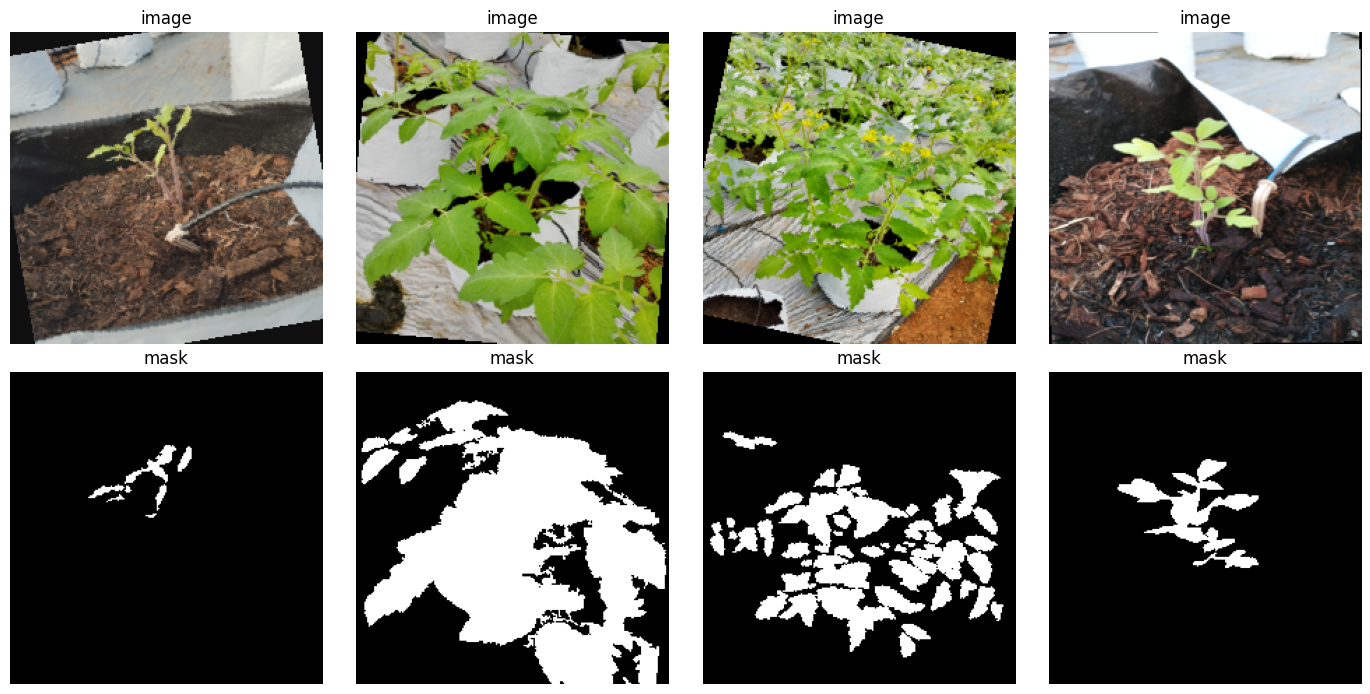

In [4]:
def denormalize(img_tensor):
    img = img_tensor.cpu().numpy().transpose(1, 2, 0)
    img = img * np.array(IMAGENET_STD) + np.array(IMAGENET_MEAN)
    return np.clip(img, 0, 1)

images, masks = next(iter(train_loader))
fig, axes = plt.subplots(2, 4, figsize=(14, 7))
for i in range(4):
    axes[0, i].imshow(denormalize(images[i]))
    axes[0, i].set_title("image")
    axes[0, i].axis("off")
    axes[1, i].imshow(masks[i].numpy(), cmap="gray")
    axes[1, i].set_title("mask")
    axes[1, i].axis("off")
plt.tight_layout()
plt.show()

## 3. Model — DeepLabV3-ResNet50, binary segmentation head

Loads the COCO-pretrained DeepLabV3-ResNet50 and replaces the final 1x1 conv (and the
auxiliary head's) with a 2-class (background/plant) version. The aux head's output is
ignored at inference; only used here if `AUX_LOSS_WEIGHT > 0` during training.

In [6]:
AUX_LOSS_WEIGHT = 0.4

def build_segmentation_model():
    m = deeplabv3_resnet50(weights=DeepLabV3_ResNet50_Weights.DEFAULT)
    m.classifier[4] = nn.Conv2d(256, 2, kernel_size=1)
    if m.aux_classifier is not None:
        m.aux_classifier[4] = nn.Conv2d(256, 2, kernel_size=1)
    return m.to(device)

seg_model = build_segmentation_model()
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(seg_model.parameters(), lr=LEARNING_RATE)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="min", factor=0.5, patience=2)

n_params = sum(p.numel() for p in seg_model.parameters() if p.requires_grad)
print(f"Trainable params: {n_params:,}")

Trainable params: 41,994,308


## 4. Training loop

Tracks per-pixel loss and mean IoU (background + plant classes) each epoch; saves the
checkpoint with the best validation IoU.

In [7]:
def mean_iou(preds, targets, num_classes=2):
    ious = []
    for c in range(num_classes):
        pred_c = preds == c
        target_c = targets == c
        intersection = (pred_c & target_c).sum().item()
        union = (pred_c | target_c).sum().item()
        if union == 0:
            continue
        ious.append(intersection / union)
    return sum(ious) / len(ious) if ious else 0.0


def run_epoch(model, loader, criterion, optimizer=None):
    is_train = optimizer is not None
    model.train() if is_train else model.eval()

    running_loss, total, iou_sum, n_batches = 0.0, 0, 0.0, 0
    with torch.set_grad_enabled(is_train):
        for images, masks in loader:
            images, masks = images.to(device), masks.to(device)

            if is_train:
                optimizer.zero_grad()

            output = model(images)
            loss = criterion(output["out"], masks)
            if is_train and model.aux_classifier is not None:
                loss = loss + AUX_LOSS_WEIGHT * criterion(output["aux"], masks)

            if is_train:
                loss.backward()
                optimizer.step()

            preds = output["out"].argmax(dim=1)
            running_loss += loss.item() * images.size(0)
            total += images.size(0)
            iou_sum += mean_iou(preds, masks)
            n_batches += 1

    return running_loss / total, iou_sum / n_batches

In [8]:
history = {"train_loss": [], "train_iou": [], "val_loss": [], "val_iou": []}
best_val_iou = 0.0
best_model_wts = copy.deepcopy(seg_model.state_dict())
best_ckpt_path = os.path.join(SEG_CHECKPOINT_DIR, "deeplabv3_leaf_seg_best.pt")

start = time.time()
for epoch in range(1, NUM_EPOCHS + 1):
    train_loss, train_iou = run_epoch(seg_model, train_loader, criterion, optimizer)
    val_loss, val_iou = run_epoch(seg_model, val_loader, criterion, optimizer=None)
    scheduler.step(val_loss)

    history["train_loss"].append(train_loss)
    history["train_iou"].append(train_iou)
    history["val_loss"].append(val_loss)
    history["val_iou"].append(val_iou)

    if val_iou > best_val_iou:
        best_val_iou = val_iou
        best_model_wts = copy.deepcopy(seg_model.state_dict())
        torch.save({
            "model_state_dict": best_model_wts,
            "epoch": epoch,
            "val_iou": val_iou,
        }, best_ckpt_path)

    print(f"Epoch {epoch:02d}/{NUM_EPOCHS} | "
          f"train_loss {train_loss:.4f} train_iou {train_iou:.4f} | "
          f"val_loss {val_loss:.4f} val_iou {val_iou:.4f}")

elapsed = time.time() - start
print(f"\nTraining complete in {elapsed // 60:.0f}m {elapsed % 60:.0f}s")
print(f"Best val IoU: {best_val_iou:.4f} (saved to {best_ckpt_path})")

seg_model.load_state_dict(best_model_wts)
seg_model.eval()

Epoch 01/15 | train_loss 0.6227 train_iou 0.5944 | val_loss 0.3813 val_iou 0.6676
Epoch 02/15 | train_loss 0.3826 train_iou 0.6824 | val_loss 0.2409 val_iou 0.7195
Epoch 03/15 | train_loss 0.3134 train_iou 0.7152 | val_loss 0.1994 val_iou 0.7507
Epoch 04/15 | train_loss 0.2814 train_iou 0.7310 | val_loss 0.1778 val_iou 0.7710
Epoch 05/15 | train_loss 0.2627 train_iou 0.7413 | val_loss 0.1675 val_iou 0.7688
Epoch 06/15 | train_loss 0.2465 train_iou 0.7470 | val_loss 0.1640 val_iou 0.7585
Epoch 07/15 | train_loss 0.2337 train_iou 0.7567 | val_loss 0.1596 val_iou 0.7722
Epoch 08/15 | train_loss 0.2245 train_iou 0.7629 | val_loss 0.1587 val_iou 0.7871
Epoch 09/15 | train_loss 0.2179 train_iou 0.7659 | val_loss 0.1559 val_iou 0.7875
Epoch 10/15 | train_loss 0.2100 train_iou 0.7712 | val_loss 0.1587 val_iou 0.7865
Epoch 11/15 | train_loss 0.2031 train_iou 0.7770 | val_loss 0.1485 val_iou 0.7894
Epoch 12/15 | train_loss 0.1988 train_iou 0.7794 | val_loss 0.1475 val_iou 0.7929
Epoch 13/15 | tr

DeepLabV3(
  (backbone): IntermediateLayerGetter(
    (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (layer1): Sequential(
      (0): Bottleneck(
        (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (downsample): Se

## 5. Training curves

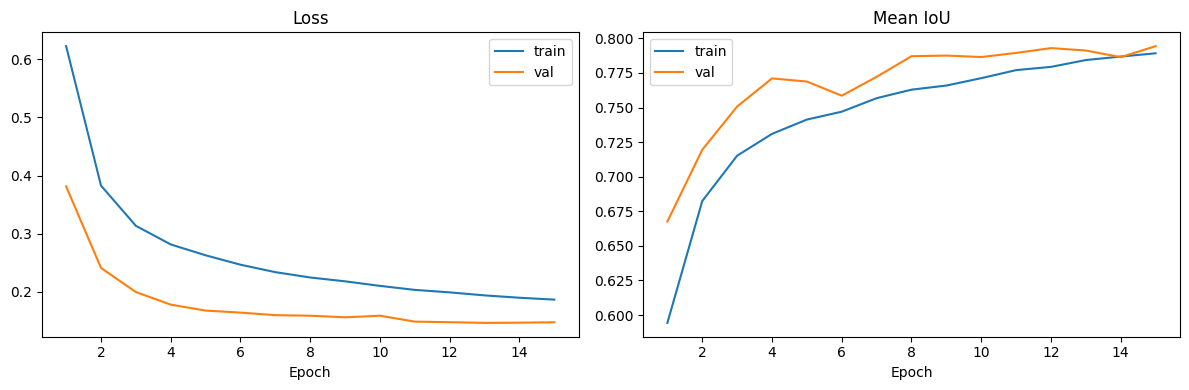

In [9]:
epochs_range = range(1, len(history["train_loss"]) + 1)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(epochs_range, history["train_loss"], label="train")
axes[0].plot(epochs_range, history["val_loss"], label="val")
axes[0].set_title("Loss")
axes[0].set_xlabel("Epoch")
axes[0].legend()

axes[1].plot(epochs_range, history["train_iou"], label="train")
axes[1].plot(epochs_range, history["val_iou"], label="val")
axes[1].set_title("Mean IoU")
axes[1].set_xlabel("Epoch")
axes[1].legend()

plt.tight_layout()
plt.show()

## 6. Evaluation on the held-out test set

Reports mean IoU on `tomato final dataset/test` (never used for training or model
selection) and shows a few predicted-mask vs. ground-truth-mask examples.

Test loss: 0.2313 | Test mean IoU: 0.7569


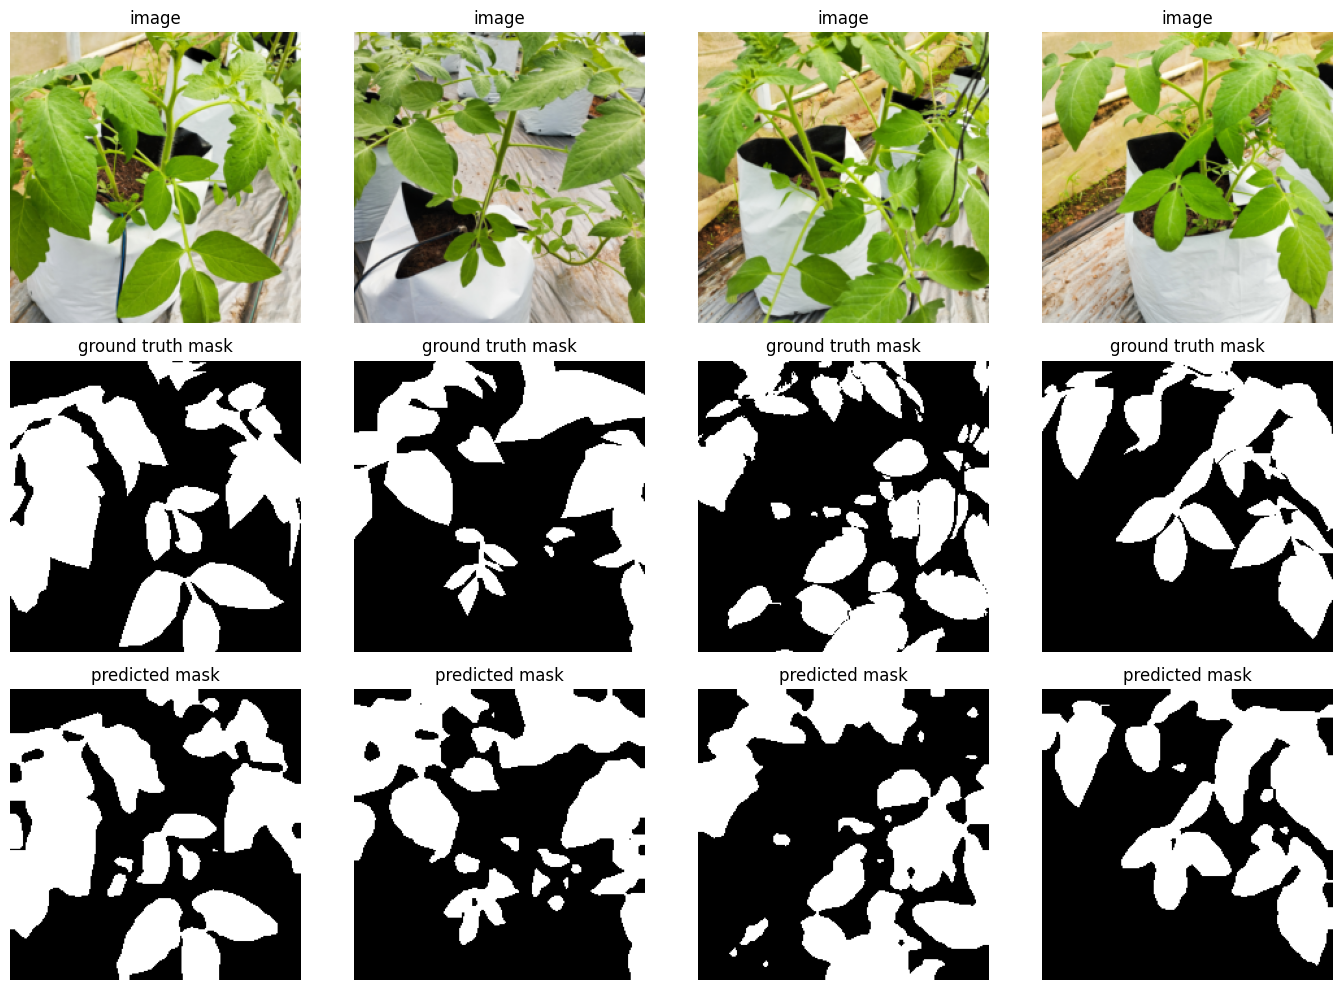

In [10]:
test_loss, test_iou = run_epoch(seg_model, test_loader, criterion, optimizer=None)
print(f"Test loss: {test_loss:.4f} | Test mean IoU: {test_iou:.4f}")

images, masks = next(iter(test_loader))
with torch.no_grad():
    preds = seg_model(images.to(device))["out"].argmax(dim=1).cpu()

fig, axes = plt.subplots(3, 4, figsize=(14, 10))
for i in range(4):
    axes[0, i].imshow(denormalize(images[i]))
    axes[0, i].set_title("image")
    axes[0, i].axis("off")
    axes[1, i].imshow(masks[i].numpy(), cmap="gray")
    axes[1, i].set_title("ground truth mask")
    axes[1, i].axis("off")
    axes[2, i].imshow(preds[i].numpy(), cmap="gray")
    axes[2, i].set_title("predicted mask")
    axes[2, i].axis("off")
plt.tight_layout()
plt.show()

## 7. Full two-stage pipeline: segment (predicted mask) -> mask -> classify

This is the realistic, deployable number: unlike the earlier masked-vs-original comparison
(which used perfect ground-truth polygons), this evaluates the classifier on masks
*predicted* by this segmentation model -- exactly what would happen on a brand-new photo
with no annotations. Uses raw (unmasked, unnormalized) test images so the predicted mask
can be applied to pixel values directly, matching how `generate_masked_dataset.py` built
the training data for the masked classifier.

Full pipeline (predicted-mask) test accuracy: 0.8500
              precision    recall  f1-score   support

  developing       0.97      0.90      0.94        41
   flowering       0.82      0.77      0.79        60
    fruiting       0.54      0.71      0.61        21
     seeding       1.00      1.00      1.00        38

    accuracy                           0.85       160
   macro avg       0.83      0.85      0.84       160
weighted avg       0.87      0.85      0.86       160



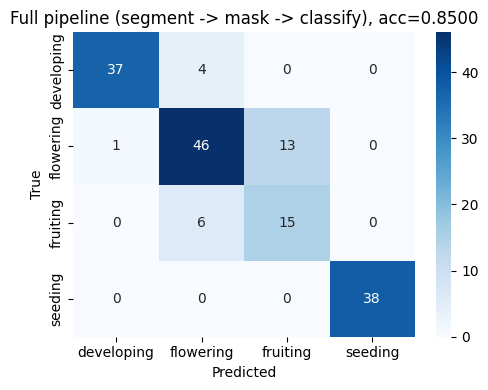


For reference: oracle ground-truth-mask accuracy (from resnet50_masked_comparison.ipynb) was 0.9187
Gap from oracle: +0.0687


In [11]:
import torch.nn.functional as F
from torchvision import transforms
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
from masked_comparison_utils import SplitFirstFolderDataset

CLASS_NAMES = ["developing", "flowering", "fruiting", "seeding"]

# Raw (0-1, unnormalized) tensors so we can apply the predicted mask to pixel values,
# then re-normalize before feeding the classifier -- mirrors generate_masked_dataset.py.
raw_transform = transforms.Compose([
    transforms.Resize(int(IMAGE_SIZE * 1.14)),
    transforms.CenterCrop(IMAGE_SIZE),
    transforms.ToTensor(),
])
normalize = transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD)

test_ds_raw = SplitFirstFolderDataset(DATA_DIR, "test", raw_transform, classes=CLASS_NAMES)
test_loader_raw = DataLoader(test_ds_raw, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)

def load_masked_classifier():
    m = models.resnet50(weights=None)
    m.fc = nn.Linear(m.fc.in_features, len(CLASS_NAMES))
    ckpt = torch.load(CLASSIFIER_CHECKPOINT_PATH, map_location=device, weights_only=False)
    m.load_state_dict(ckpt["model_state_dict"])
    return m.to(device).eval()

classifier = load_masked_classifier()
seg_model.eval()

all_preds, all_labels = [], []
with torch.no_grad():
    for raw_images, labels in test_loader_raw:
        raw_images = raw_images.to(device)

        norm_images = normalize(raw_images)
        pred_masks = seg_model(norm_images)["out"].argmax(dim=1, keepdim=True).float()  # B,1,H,W

        masked_raw = raw_images * pred_masks  # black out predicted background
        masked_norm = normalize(masked_raw)

        outputs = classifier(masked_norm)
        preds = outputs.argmax(dim=1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(labels.numpy() if hasattr(labels, "numpy") else labels)

pipeline_acc = (np.array(all_preds) == np.array(all_labels)).mean()
print(f"Full pipeline (predicted-mask) test accuracy: {pipeline_acc:.4f}")
print(classification_report(all_labels, all_preds, target_names=CLASS_NAMES))

cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title(f"Full pipeline (segment -> mask -> classify), acc={pipeline_acc:.4f}")
plt.tight_layout()
plt.show()

print(f"\nFor reference: oracle ground-truth-mask accuracy (from resnet50_masked_comparison.ipynb) was 0.9187")
print(f"Gap from oracle: {0.9187 - pipeline_acc:+.4f}")

## 8. Export

Exports the segmentation model and a combined standalone inference script (segment ->
mask -> classify) for the fusion project, into `export_leaf_pipeline/`.

In [12]:
import json
import datetime

EXPORT_DIR = os.path.join(PROJECT_ROOT, "export_leaf_pipeline")
os.makedirs(EXPORT_DIR, exist_ok=True)

seg_ckpt = torch.load(best_ckpt_path, map_location="cpu", weights_only=False)
torch.save(seg_ckpt["model_state_dict"], os.path.join(EXPORT_DIR, "deeplabv3_leaf_seg.pth"))

classifier_ckpt = torch.load(CLASSIFIER_CHECKPOINT_PATH, map_location="cpu", weights_only=False)
torch.save(classifier_ckpt["model_state_dict"], os.path.join(EXPORT_DIR, "resnet50_leaf_classifier.pth"))

metadata = {
    "pipeline": "segment (DeepLabV3-ResNet50, binary plant/background) -> mask raw image -> "
                "classify (ResNet50, trained on masked images)",
    "segmentation_model": {
        "architecture": "deeplabv3_resnet50",
        "num_classes": 2,
        "class_meaning": {"0": "background", "1": "plant/leaf"},
        "best_epoch": int(seg_ckpt["epoch"]),
        "val_iou_at_best_epoch": float(seg_ckpt["val_iou"]),
        "test_mean_iou": float(test_iou),
    },
    "classifier_model": {
        "architecture": "resnet50",
        "num_classes": len(CLASS_NAMES),
        "class_names": CLASS_NAMES,
        "trained_on": "tomato final dataset_masked (ground-truth-masked images)",
    },
    "input_size": [224, 224, 3],
    "normalization": {"mean": IMAGENET_MEAN, "std": IMAGENET_STD},
    "full_pipeline_test_accuracy": float(pipeline_acc),
    "oracle_ground_truth_mask_test_accuracy": 0.9187,
    "note": "full_pipeline_test_accuracy uses masks PREDICTED by the segmentation model "
            "(realistic, deployable number for new/unannotated photos); the oracle figure "
            "used perfect ground-truth polygon masks and is not achievable on new images.",
    "training_date": datetime.date.today().isoformat(),
    "framework": {"torch": torch.__version__, "torchvision": __import__("torchvision").__version__},
}
with open(os.path.join(EXPORT_DIR, "metadata.json"), "w", encoding="utf-8") as f:
    json.dump(metadata, f, indent=2)

print("Exported to", EXPORT_DIR)

Exported to d:\Reasearch\Resnet50test\export_leaf_pipeline


In [13]:
pipeline_code = '''"""Standalone leaf-focused tomato growth-stage inference pipeline.
Segments the plant/leaf region out of a raw photo, blacks out the background, then
classifies growth stage. No dependency on this project\'s training code -- copy-paste
into another project alongside deeplabv3_leaf_seg.pth and resnet50_leaf_classifier.pth.
"""
import torch
import torch.nn as nn
from torchvision import transforms, models
from torchvision.models.segmentation import deeplabv3_resnet50

CLASS_NAMES = {class_names!r}
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

RAW_TRANSFORM = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
])
NORMALIZE = transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD)


def load_leaf_pipeline(seg_checkpoint_path, classifier_checkpoint_path, device=None):
    """Returns (segmentation_model, classifier_model), both in eval() mode on device."""
    if device is None:
        device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    device = torch.device(device) if not isinstance(device, torch.device) else device

    seg_model = deeplabv3_resnet50(weights=None)
    seg_model.classifier[4] = nn.Conv2d(256, 2, kernel_size=1)
    if seg_model.aux_classifier is not None:
        seg_model.aux_classifier[4] = nn.Conv2d(256, 2, kernel_size=1)
    seg_state = torch.load(seg_checkpoint_path, map_location=device, weights_only=True)
    seg_model.load_state_dict(seg_state)
    seg_model = seg_model.to(device).eval()

    classifier = models.resnet50(weights=None)
    classifier.fc = nn.Linear(classifier.fc.in_features, len(CLASS_NAMES))
    clf_state = torch.load(classifier_checkpoint_path, map_location=device, weights_only=True)
    classifier.load_state_dict(clf_state)
    classifier = classifier.to(device).eval()

    return seg_model, classifier


def predict_growth_stage(image_pil, seg_model, classifier, device=None):
    """image_pil: a PIL.Image (RGB). Returns (predicted_class_name, probs_dict)."""
    if device is None:
        device = next(classifier.parameters()).device

    raw = RAW_TRANSFORM(image_pil.convert("RGB")).unsqueeze(0).to(device)
    with torch.no_grad():
        norm = NORMALIZE(raw)
        pred_mask = seg_model(norm)["out"].argmax(dim=1, keepdim=True).float()
        masked_raw = raw * pred_mask
        masked_norm = NORMALIZE(masked_raw)
        logits = classifier(masked_norm)
        probs = torch.softmax(logits, dim=1)[0].cpu().numpy()

    pred_idx = int(probs.argmax())
    return CLASS_NAMES[pred_idx], dict(zip(CLASS_NAMES, probs.tolist()))
'''.format(class_names=CLASS_NAMES)

with open(os.path.join(EXPORT_DIR, "leaf_pipeline.py"), "w", encoding="utf-8") as f:
    f.write(pipeline_code)

print("Wrote", os.path.join(EXPORT_DIR, "leaf_pipeline.py"))

Wrote d:\Reasearch\Resnet50test\export_leaf_pipeline\leaf_pipeline.py


In [15]:
# Fresh-process sanity test of the exported pipeline on a few test images
import importlib.util
spec = importlib.util.spec_from_file_location("leaf_pipeline", os.path.join(EXPORT_DIR, "leaf_pipeline.py"))
leaf_pipeline = importlib.util.module_from_spec(spec)
spec.loader.exec_module(leaf_pipeline)

seg_m, clf_m = leaf_pipeline.load_leaf_pipeline(
    os.path.join(EXPORT_DIR, "deeplabv3_leaf_seg.pth"),
    os.path.join(EXPORT_DIR, "resnet50_leaf_classifier.pth"),
)

from PIL import Image as PILImage
sample_paths = [
    (os.path.join(DATA_DIR, "test", "developing"), "developing"),
    (os.path.join(DATA_DIR, "test", "flowering"), "flowering"),
    (os.path.join(DATA_DIR, "test", "fruiting"), "fruiting"),
    (os.path.join(DATA_DIR, "test", "seeding"), "seeding"),
]
for folder, true_label in sample_paths:
    fname = sorted(f for f in os.listdir(folder) if f.lower().endswith(".jpg"))[0]
    img = PILImage.open(os.path.join(folder, fname))
    pred_label, probs = leaf_pipeline.predict_growth_stage(img, seg_m, clf_m)
    print(f"true={true_label:<12} pred={pred_label:<12} probs={ {k: round(v,3) for k,v in probs.items()} }")

true=developing   pred=developing   probs={'developing': 0.998, 'flowering': 0.001, 'fruiting': 0.001, 'seeding': 0.0}
true=flowering    pred=flowering    probs={'developing': 0.485, 'flowering': 0.504, 'fruiting': 0.009, 'seeding': 0.002}
true=fruiting     pred=fruiting     probs={'developing': 0.062, 'flowering': 0.119, 'fruiting': 0.817, 'seeding': 0.002}
true=seeding      pred=seeding      probs={'developing': 0.001, 'flowering': 0.001, 'fruiting': 0.001, 'seeding': 0.998}


In [16]:
# ==== Train / Valid / Test accuracy summary ====

# --- Segmentation model: pixel-level accuracy + mean IoU, all 3 splits ---
def pixel_accuracy_and_iou(model, loader):
    model.eval()
    correct, total = 0, 0
    iou_sum, n_batches = 0.0, 0
    with torch.no_grad():
        for images, masks in loader:
            images, masks = images.to(device), masks.to(device)
            preds = model(images)["out"].argmax(dim=1)
            correct += (preds == masks).sum().item()
            total += masks.numel()
            iou_sum += mean_iou(preds, masks)
            n_batches += 1
    return correct / total, iou_sum / n_batches

seg_train_acc, seg_train_iou = pixel_accuracy_and_iou(seg_model, train_loader)
seg_val_acc, seg_val_iou = pixel_accuracy_and_iou(seg_model, val_loader)
seg_test_acc, seg_test_iou = pixel_accuracy_and_iou(seg_model, test_loader)

print("=== Segmentation model (plant vs. background, pixel-level) ===")
print(f"Train: pixel_accuracy={seg_train_acc:.4f}  mean_IoU={seg_train_iou:.4f}")
print(f"Valid: pixel_accuracy={seg_val_acc:.4f}  mean_IoU={seg_val_iou:.4f}")
print(f"Test:  pixel_accuracy={seg_test_acc:.4f}  mean_IoU={seg_test_iou:.4f}")

# --- Leaf classifier: growth-stage accuracy on masked images, all 3 splits ---
DATA_DIR_MASKED = os.path.join(PROJECT_ROOT, "tomato final dataset_masked")
clf_eval_transform = transforms.Compose([
    transforms.Resize(int(IMAGE_SIZE * 1.14)),
    transforms.CenterCrop(IMAGE_SIZE),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

clf_train_ds = SplitFirstFolderDataset(DATA_DIR_MASKED, "train", clf_eval_transform, classes=CLASS_NAMES)
clf_val_ds = SplitFirstFolderDataset(DATA_DIR_MASKED, "valid", clf_eval_transform, classes=CLASS_NAMES)
clf_test_ds = SplitFirstFolderDataset(DATA_DIR_MASKED, "test", clf_eval_transform, classes=CLASS_NAMES)

clf_train_loader = DataLoader(clf_train_ds, batch_size=BATCH_SIZE, shuffle=False)
clf_val_loader = DataLoader(clf_val_ds, batch_size=BATCH_SIZE, shuffle=False)
clf_test_loader = DataLoader(clf_test_ds, batch_size=BATCH_SIZE, shuffle=False)

def classifier_accuracy(clf, loader):
    clf.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            preds = clf(images).argmax(dim=1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)
    return correct / total

clf_train_acc = classifier_accuracy(classifier, clf_train_loader)
clf_val_acc = classifier_accuracy(classifier, clf_val_loader)
clf_test_acc = classifier_accuracy(classifier, clf_test_loader)

print("\n=== Leaf classifier (growth stage, on ground-truth-masked images) ===")
print(f"Train: accuracy={clf_train_acc:.4f}")
print(f"Valid: accuracy={clf_val_acc:.4f}")
print(f"Test:  accuracy={clf_test_acc:.4f}")

# --- Full two-stage pipeline: already computed as pipeline_acc (test-only, ---
# --- since it's the deployable number -- train/valid don't apply the same way) ---
print("\n=== Full pipeline (segment -> mask -> classify), on RAW/unmasked images ===")
print(f"Test:  accuracy={pipeline_acc:.4f}   <- the realistic, deployable number")

=== Segmentation model (plant vs. background, pixel-level) ===
Train: pixel_accuracy=0.9450  mean_IoU=0.7990
Valid: pixel_accuracy=0.9376  mean_IoU=0.7943
Test:  pixel_accuracy=0.9039  mean_IoU=0.7569

=== Leaf classifier (growth stage, on ground-truth-masked images) ===
Train: accuracy=0.9810
Valid: accuracy=0.9778
Test:  accuracy=0.9187

=== Full pipeline (segment -> mask -> classify), on RAW/unmasked images ===
Test:  accuracy=0.8500   <- the realistic, deployable number
